# April 8, 2024 Eclipse TDOA Analysis (Figures 11 and 12)

Recreates the layer-height time series for Figures 11 (N5DUP) and 12 (AB5YO). Data and samples live in `../data`, and outputs save next to this notebook in `fig_11_N5DUP2024.jpg` and `fig_12_2024Res.jpg`.


## Setup
- Configure paths so the notebook can be run from `fig_11_12/notebooks`.
- Imports the shared eclipse calculation helpers.


### How to run
- Create/activate the conda env in `fig_11_12/environment.yml` (Python 3.12, numpy<2, astropy, matplotlib, scipy, pandas).
- Run this notebook **from `fig_11_12/notebooks/`** so the relative data paths resolve.
- Inputs: WAV recordings in `../data/recordings/` and chirp templates in `../data/samples/`.
- Outputs: `fig_11_N5DUP2024.jpg` and `fig_12_2024Res.jpg` saved in this folder.


In [1]:
from pathlib import Path
import sys
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
from scipy import signal
from scipy.io import wavfile

# Notebook is expected to run from fig_11_12/notebooks
NOTEBOOK_DIR = Path.cwd()
FIG_ROOT = NOTEBOOK_DIR.parent
REPO_ROOT = FIG_ROOT.parent
DATA_DIR = FIG_ROOT / "data"
RECORDING_DIR = DATA_DIR / "recordings"
SAMPLES_DIR = DATA_DIR / "samples"
OUTPUT_FIG11 = NOTEBOOK_DIR
OUTPUT_FIG12 = NOTEBOOK_DIR

sys.path.append(str(REPO_ROOT))
import eclipse_calc
import eclipse_calculator

%matplotlib inline


## Plot style

In [2]:
# Consistent plotting defaults
mpl.rcParams['font.size'] = 16
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.grid'] = True
mpl.rcParams['grid.linestyle'] = ':'
mpl.rcParams['figure.figsize'] = (12, 9)
mpl.rcParams['axes.xmargin'] = 0
mpl.rcParams['axes.ymargin'] = 0.1


## Signal processing helpers

In [3]:
def load_wav(fname, normalize=True):
    """Load a WAV file.

Args:
    fname: Path to the WAV file.
    normalize: If True, scale samples to [-1, 1].
Returns:
    tuple[pandas.DataFrame, float]: Time-indexed dataframe and sampling rate (Hz).
"""
    fs, x0 = wavfile.read(fname)
    if normalize:
        x0 = x0 / float(np.max(np.abs(x0)))
    k = np.arange(len(x0))
    Ts = 1 / fs
    t = k * Ts
    df = pd.DataFrame({'time': t, 'x': x0}).set_index('time')
    return df, fs


def process(filepath):
    """Envelope and high-pass filter a waveform.

Args:
    filepath: Path to a WAV file.
Returns:
    tuple[pandas.DataFrame, numpy.ndarray, float]: Envelope dataframe, filtered series, and sampling rate (Hz).
"""
    x0, fs = load_wav(filepath)
    x1 = x0 ** 2
    Tc = 1.2e-3
    env = x1.rolling(int(Tc * fs), center=True).max().dropna()
    wp = 250
    ws = 1.1 * wp
    gpass = 3
    gstop = 40
    N, Wn = signal.buttord(wp, ws, gpass, gstop, analog=False, fs=fs)
    b, a = signal.butter(N, Wn, btype='highpass', analog=False, output='ba', fs=fs)
    x_filt = signal.lfilter(b, a, env.to_numpy().flatten())
    env['x_hp'] = x_filt
    return env, x_filt, fs


def find_max(X, freq, minfreq, maxfreq):
    """Find the frequency of the maximum PSD peak in the given range.

Args:
    X: PSD array.
    freq: Frequency array (Hz).
    minfreq: Lower bound (Hz).
    maxfreq: Upper bound (Hz).
Returns:
    float: Peak frequency (Hz).
"""
    if maxfreq == 0:
        maxfreq = 10000
    start = np.argwhere(freq >= minfreq)[0][0]
    end = np.argwhere(freq <= maxfreq)[-1:][0][0]
    maxima = max(X[start:end])
    maximum = np.argwhere(X == maxima)
    maximum = abs(freq[maximum][0])
    return maximum



def new_plot_sig(df, column='x', title=None, tlim=None, flim=None, plot_fft=False, peaktime='', minfreq=0, maxfreq=10000):
    """Window a slice of the signal and optionally plot its FFT.

Args:
    df: Dataframe with a time index and signal column.
    column: Column name to analyze.
    title: Title for the plot.
    tlim: (start, stop) seconds window.
    flim: Frequency limits (Hz).
    plot_fft: Whether to render the FFT plot.
    peaktime: Identifier used in labels.
    minfreq: Lower frequency bound (Hz).
    maxfreq: Upper frequency bound (Hz).
Returns:
    tuple[numpy.ndarray, numpy.ndarray]: PSD values and corresponding frequencies.
"""
    x = df[column]
    tvec = df.index
    Ts = tvec[1] - tvec[0]

    if tlim is None:
        tlim = (0, float(np.max(tvec)))
        xt = x
    else:
        tf = np.logical_and(tvec >= tlim[0], tvec < tlim[1])
        xt = x[tf].copy()

    han_win = np.hanning(len(xt))
    x_han = han_win * xt
    nfft = len(x_han)
    if nfft < 2 ** 16:
        nfft = 2 ** 16

    X_psd = np.abs(np.fft.fftshift(np.fft.fft(x_han, n=nfft) * Ts * 2)) ** 2
    f = np.fft.fftshift(np.fft.fftfreq(nfft, Ts))

    if plot_fft:
        if maxfreq == 0:
            maxfreq = 10000
        flim = (0, maxfreq)
        start = np.argwhere(f >= minfreq)[0][0]
        end = np.argwhere(f <= maxfreq)[-1:][0][0]

        maxima = max(X_psd[start:end])
        maximum = np.argwhere(X_psd == maxima)
        maximum = abs(f[maximum][0])
        peaktime = str(peaktime[0]) + '_' + str(peaktime[1] + 1)

        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(2, 1, 1)
        bx = fig.add_subplot(2, 1, 2)
        bx.plot(tvec, x)
        bx.set_xlim(tlim)

        ax.plot(f, X_psd)
        ax.plot([maximum, maximum], [0, max(X_psd)], linewidth=2)
        ax.plot([minfreq, minfreq], [0, max(X_psd)], linewidth=3, color='black')

        ax.plot([0, maximum[0]], [max(X_psd), max(X_psd)], linewidth=2, color='red')
        ax.plot([0, maximum[0]], [maxima, maxima], linewidth=2, color='green')

        ax.scatter(maximum, maxima, linewidths=5, label=str(maximum[0])[:5] + " Hz", color='green')
        ax.scatter(f[signal.find_peaks(X_psd)[0]], X_psd[signal.find_peaks(X_psd)[0]], color='black')

        ax.set_xlabel('Frequency [Hz]')
        ax.set_ylabel('PSD')
        ax.set_xlim(flim)
        ax.legend()

        ax2 = ax.twiny()
        ax2.xaxis.set_ticks_position('bottom')
        ax2.xaxis.set_label_position('bottom')
        ax2.spines['bottom'].set_position(('axes', -0.15))
        ax2.set_frame_on(True)
        ax2.patch.set_visible(False)
        newlabels = np.arange(0, flim[1] + 1, flim[1] / 12)
        ax2.set_xticks(np.arange(0, len(newlabels)))
        ax2.set_xticklabels(newlabels / minfreq)
        ax2.ticklabel_format()
        ax2.set_xlabel('TDOA [ms]')

        plt.tight_layout()
        plt.show()
        plt.close(fig)

    return X_psd, f


def find_starting_points(sample, wav_list, plot_start=False):
    """Locate chirp start times via correlation with a template sample.

Args:
    sample: Template waveform segment.
    wav_list: List of WAV file paths.
    plot_start: If True, plot correlation diagnostics.
Returns:
    list[float]: Start times (seconds) for each file.
"""
    starting_times = []
    for fpath in wav_list:
        wav_env_x, wav_fs = load_wav(fpath)
        wav_env_x = wav_env_x['x']
        correlation = signal.correlate(wav_env_x, sample, mode='same')
        corrmax = (np.argwhere(correlation == max(correlation[0:len(correlation) // 2])))
        corrmax = (corrmax[0][0]) / wav_fs
        starting_times.append(corrmax)

        if plot_start:
            tlim = (corrmax - 3, corrmax + 5)
            tau = np.arange(len(wav_env_x)) * (1 / wav_fs)

            fig = plt.figure(figsize=(15, 8))
            ax = fig.add_subplot(3, 1, 1)
            xx = np.arange(len(sample)) * (1 / wav_fs)
            ax.plot(xx, sample)
            ax.set_title("Sample")
            ax.set_xlabel("time [seconds]")

            ax = fig.add_subplot(3, 1, 2)
            ax.plot(tau, wav_env_x)
            ax.plot([corrmax, corrmax], [-.5, .5])
            ax.set_xlim(tlim)
            ax.set_title(fpath)

            ax = fig.add_subplot(3, 1, 3)
            ax.plot(tau, correlation)
            ax.axvline(corrmax, color='yellow')
            ax.set_title(fpath)

            fig.tight_layout()
            plt.show()
            plt.close(fig)
            break
    return starting_times


def find_beat_notes(wav_list, starting_times, range_gates, plot_fft=False):
    """Extract beat-note frequencies using range gates around expected peaks.

Args:
    wav_list: WAV file paths.
    starting_times: Chirp start times for each file (seconds).
    range_gates: [t_start, t_stop, minfreq, maxfreq, offset] gating parameters.
    plot_fft: If True, render FFT plots.
Returns:
    numpy.ndarray: Beat-note frequencies per file.
"""
    all_beats = []
    for file_num, fpath in enumerate(wav_list):
        wav_env, _, _ = process(fpath)
        peaks = []
        for i in range(5):
            base = starting_times[file_num] + range_gates[4]
            peaks.append(base + 0.75 * i)
            peaks.append(base + 0.75 * 4 + (0.75 * i) + 1.111)

        peaks = np.array(peaks).flatten()
        maxes = []
        for peak_num, peak in enumerate(peaks):
            tlim = (peak + range_gates[0], peak + range_gates[1])
            minfreq = range_gates[2]
            maxfreq = range_gates[3]
            X, freq = new_plot_sig(wav_env, title=fpath, tlim=tlim, peaktime=[5, peak_num], plot_fft=plot_fft, minfreq=minfreq, maxfreq=maxfreq)
            maximum = find_max(X, freq, minfreq, maxfreq)
            maxes.append(maximum)
        all_beats.append(np.array(maxes).flatten())
    return np.array(all_beats)


## Load datasets and samples

In [4]:
BASE_DATE = dt.date(2024, 4, 8)


def to_mono(paths):
    """Ensure each WAV file is mono by averaging channels in-place.

Args:
    paths: Iterable of WAV file paths.
Returns:
    None
"""
    for path in paths:
        fs, data = wavfile.read(path)
        if hasattr(data, 'ndim') and data.ndim > 1 and data.shape[1] > 1:
            mono = np.mean(data, axis=1)
            mono = np.asarray(mono, dtype=data.dtype)
            wavfile.write(path, fs, mono)


def list_dataset(directory, predicate):
    """Return sorted WAV files in a directory filtered by predicate; enforces mono.

Args:
    directory: Directory containing WAV files.
    predicate: Callable that accepts filename and returns True to include.
Returns:
    list[str]: Full paths to matching WAV files.
"""
    files = []
    for name in sorted(Path(directory).iterdir()):
        if name.is_file() and name.name.lower().endswith('.wav') and predicate(name.name):
            files.append(str(name))
    to_mono(files)
    return files


def parse_times(file_list, hour_slice, minute_slice):
    """Parse HHMM timestamps embedded in filenames into datetime objects.

Args:
    file_list: List of filenames/paths.
    hour_slice: Tuple(start, stop) slice indices for hour.
    minute_slice: Tuple(start, stop) slice indices for minute.
Returns:
    list[datetime]: Parsed datetimes on BASE_DATE.
"""
    times = []
    for path in file_list:
        name = Path(path).name
        hour = int(name[hour_slice[0]:hour_slice[1]])
        minute = int(name[minute_slice[0]:minute_slice[1]])
        times.append(dt.datetime(BASE_DATE.year, BASE_DATE.month, BASE_DATE.day, hour, minute))
    return times


dataset_configs = {
    'N5DUP_40m': {
        'directory': RECORDING_DIR / '40M_TX-WA5FRF_RX-N5DUP_318km',
        'predicate': lambda n: n[4:10] == 'EL09nn',
        'hour_slice': (18, 20),
        'minute_slice': (20, 22),
    },
    'AB5YO_40m': {
        'directory': RECORDING_DIR / '40mAB5YO',
        'predicate': lambda n: n.startswith('2404'),
        'hour_slice': (7, 9),
        'minute_slice': (9, 11),
    },
    'AB5YO_60m': {
        'directory': RECORDING_DIR / '60mAB5YO',
        'predicate': lambda n: n.startswith('2404'),
        'hour_slice': (7, 9),
        'minute_slice': (9, 11),
    },
}

wavlists = {}
times_by_dataset = {}
for name, cfg in dataset_configs.items():
    files = list_dataset(cfg['directory'], cfg['predicate'])
    wavlists[name] = files
    times_by_dataset[name] = parse_times(files, cfg['hour_slice'], cfg['minute_slice'])

wavlist_40m = wavlists['N5DUP_40m']
fortyBand_times = times_by_dataset['N5DUP_40m']

wavlist_40mSam = wavlists['AB5YO_40m']
fortymSamBand_times = times_by_dataset['AB5YO_40m']

wavlist_60mSam = wavlists['AB5YO_60m']
sixtymSamBand_times = times_by_dataset['AB5YO_60m']

print(f"Loaded {len(wavlist_40m)} N5DUP 40 m files")
print(f"Loaded {len(wavlist_40mSam)} AB5YO 40 m files")
print(f"Loaded {len(wavlist_60mSam)} AB5YO 60 m files")


Loaded 32 N5DUP 40 m files
Loaded 49 AB5YO 40 m files
Loaded 39 AB5YO 60 m files


In [5]:
def load_sample(name):
    """Load a named chirp template from the samples directory and return its waveform.

Args:
    name: Base filename (without .wav).
Returns:
    pandas.Series: Waveform values indexed by time.
"""
    df, _ = load_wav(SAMPLES_DIR / f"{name}.wav")
    return df['x']

sample_40m = load_sample('CorrelationV7')
sample_40mSam = load_sample('CorrelationV7')
sample_60mSam = load_sample('CorrelationV8')


## Locate chirp start times

In [6]:
start_times_40 = find_starting_points(sample_40m[0.3:0.4], wavlist_40m, plot_start=False)
start_times_Sam40 = find_starting_points(sample_40mSam[0.3:0.4], wavlist_40mSam, plot_start=False)
start_times_Sam60 = find_starting_points(sample_60mSam[1:1.5], wavlist_60mSam, plot_start=False)


## Beat-note extraction

### Dataset filters and range gates
- Filenames encode timestamps; the dataset config slices HHMM to build `times` lists.
- `fortym_range_gates` and `sixtymSam_range_gates` bracket the expected beat-note peaks (seconds offset and Hz limits).
- Adjust predicates/slices or gates here if you add new stations/bands or retune the chirp spacing.


In [7]:
fortym_range_gates = [-0.4, 0.5, 10, 3 * 10, 4.8]
sixtymSam_range_gates = [-0.1, 0.25, 1, 10 * 3, 4.1]
sixtym_range_gates = [-0.4, 0.4, 10, 10 * 3, 4.9]

beats_40m = find_beat_notes(wavlist_40m, start_times_40, fortym_range_gates, plot_fft=False)
beats_40mSam = find_beat_notes(wavlist_40mSam, start_times_Sam40, fortym_range_gates, plot_fft=False)
beats_60mSam = find_beat_notes(wavlist_60mSam, start_times_Sam60, sixtymSam_range_gates, plot_fft=False)


## Reference tables (manual/auto) and solar context

In [8]:
ManuallyDecodedN5DUP40m = [1.62, 1.59, 1.72, 1.88, 1.89, 1.82, 1.9, 1.96, 1.95, 1.89, 1.96, 1.94, 2.02, 1.89, 1.8, 1.82, 1.89, 1.67, 1.76, 1.83, 1.85, 1.75, 1.87, 1.75, 1.97, 1.98, 1.87, 2.04, 1.92, 1.85, 1.72, 1.92, 1.71]
ManuallyDecodedAB5YO40m = [1.72, 1.69, 1.80, 1.84, 1.86, 1.86, 1.94, 1.90, 1.88, 2.04, 2.04, 2.04, 2.08, 2.08, 2.02, 1.94, 1.92, 1.97, 1.97, 1.86, 1.90, 1.91, 1.90, 1.91, 1.82, 1.91, 1.84, 1.84, 1.76, 1.93, 1.97, 1.97, 1.99, 2.05, 2.01, 2.00, 1.99, 2.02, 2.02, 2.02, 2.01, 1.97, 1.96, 1.92, 1.93, 1.95, 1.91, 1.90, 1.91, 1.89]
ManuallyDecodedAB5YO60m = [1.61, 1.52, 1.59, 1.54, 1.64, 1.61, 1.64, 1.67, 1.60, 1.67, 1.64, 1.72, 1.63, 1.82, 1.75, 1.65, 1.85, 2.00, 1.72, 1.80, 1.92, 1.85, 1.92, 2.00, 2.09, 1.96, 1.92, 1.85, 1.75, 1.89, 1.89, 1.89, 1.85, 1.82, 1.72, 1.65, 1.57, 1.65, 1.68, 1.77]

AutoCorrelatedN5DUP40m = [1.681, 1.719, 1.473, np.NaN, 2.030, 1.879, 1.719, 2.106, np.NaN, 1.851, 1.785, 2.068, 1.898, 1.775, np.NaN, 1.719, np.NaN, 1.605, 1.804, np.NaN, 1.870, 1.860, 1.917, 2.002, np.NaN, 2.162, np.NaN, 2.068, 1.936, 1.974, 1.964, 1.700]
AutoCorrelatedAB5YO40m = [1.700, 1.728, 1.737, 1.804, 1.785, 1.870, 1.775, 1.879, 1.841, 1.898, 2.002, 1.804, 2.040, np.NaN, 2.030, 1.945, 2.011, 1.926, 1.879, 1.926, 1.841, 1.860, 1.974, 2.077, 1.766, 1.851, 1.775, np.NaN, 1.709, np.NaN, 1.898, np.NaN, 1.813, np.NaN, np.NaN, np.NaN, 1.889, np.NaN, 1.889, np.NaN, np.NaN, 2.040, np.NaN, 1.917, np.NaN, 1.945, np.NaN, 1.785, 1.79, np.NaN]
AutoCorrelatedAB5YO60m = [1.5625, 1.635, 1.635, 1.688, 1.510, 1.802, 1.583, 1.938, 1.635, 1.656, 1.781, 1.906, 1.875, 1.917, 1.635, 1.885, 1.698, 1.552, 1.760, 1.938, 1.979, 1.958, 2.104, 2.104, 1.896, 1.969, 1.771, 1.802, 1.885, 1.875, 1.740, 1.844, 1.792, 1.865, 1.948, 1.583, 1.563, 1.635, 1.615, 1.553]

IonosondeLayer_Height = [263, 258.2, 253.2, 246.7, 249.7, 254.8, 249.8, 253, 252, 265.7, 275.6, 279.7, 275.5, 277.7, 279.2, 270.8, 263.5, 265.8, 283.6, 286, 298.1, 295.5, 297.2, 292.7, 295.6, 299.7, 296.4, 293, 288.3, 284.5, 280.7, 285, 298.6, 287.8, 286.5, 279.3, 283.8, 296.8, 289.1, 300.3, 291.9, 288.9, 300.4, 295.8, 289.4, 292, 300.7, 290.9, 307.4, 304.7, 292.8, 302.3, 313.6, 308.7, 300, 291.7, 302.4, 303.7, 301, 306.2, 298.3, 284.9, 291.4, 293.8, 292.5, 302.4, 286.6, 285.9, 276.5, 288, 286.5, 278.9, 275.9, 270.6, 280.7, 276.1, 273.1, 275.7, 279.2, 299.5, 290.9, 285.8, 278.9, 281, 288.8, 279.9, 281, 277.4, 277, 271.5, 276.9]
Ionosonde_times = [
    "14:00:05", "14:05:05", "14:10:05", "14:15:05", "14:20:05", "14:25:05", "14:30:05", "14:35:05", "14:40:05", "14:45:05",
    "14:50:05", "14:55:05", "15:00:05", "15:05:05", "15:10:05", "15:15:05", "15:20:05", "15:25:05", "15:30:05", "15:35:05",
    "15:40:05", "15:45:05", "15:50:05", "15:55:05", "16:00:05", "16:05:05", "16:10:05", "16:15:05", "16:20:05", "16:25:05",
    "16:30:05", "16:35:05", "16:40:05", "16:45:05", "16:50:05", "16:55:05", "17:00:05", "17:05:05", "17:10:05", "17:15:05",
    "17:20:05", "17:25:05", "17:30:05", "17:35:05", "17:40:05", "17:45:05", "17:50:05", "17:55:05", "18:00:05", "18:05:05",
    "18:10:05", "18:15:05", "18:20:05", "18:25:05", "18:30:05", "18:35:05", "18:40:05", "18:45:05", "18:50:05", "18:55:05",
    "19:00:05", "19:05:05", "19:10:05", "19:15:05", "19:20:05", "19:25:05", "19:30:05", "19:35:05", "19:40:05", "19:45:05",
    "19:50:05", "19:55:05", "20:00:05", "20:05:05", "20:10:05", "20:15:05", "20:20:05", "20:25:05", "20:30:05", "20:35:05",
    "20:40:05", "20:45:05", "20:50:05", "20:55:05", "21:00:05", "21:05:05", "21:10:05", "21:15:05", "21:20:05", "21:25:05",
    "21:30:05"
]

Ionosonde_datetimes = [dt.datetime.strptime("2024-04-08 " + time_str, "%Y-%m-%d %H:%M:%S") for time_str in Ionosonde_times]

lat_AB = 29.57499
lon_AB = -98.88718
lat_N5 = 30.9
lon_N5 = -99.3

sTime = dt.datetime(2024, 4, 8, 13, 0)
eTime = dt.datetime(2024, 4, 8, 23, 0)
dt_step = dt.timedelta(minutes=1)
eclipse_times = [sTime]
while eclipse_times[-1] < eTime:
    eclipse_times.append(eclipse_times[-1] + dt_step)

obsc_AB = eclipse_calc.calculate_obscuration(eclipse_times, lat_AB, lon_AB)
obsc_N5 = eclipse_calculator.calculate_obscuration(eclipse_times, lat_N5, lon_N5)

solarAB = eclipse_calculator.solarContext.solarTimeseries(sTime, eTime, lat_AB, lon_AB)
solarN5 = eclipse_calculator.solarContext.solarTimeseries(sTime, eTime, lat_N5, lon_N5)


## Plotting helpers

In [9]:
def _layer_heights(TDOAs, set_name, manual_TDOAs, correlated_TDOAS):
    """Convert TDOAs to layer heights; applies special scaling for the N5DUP path.

Args:
    TDOAs: Array of time differences (ms).
    set_name: Dataset label.
    manual_TDOAs: Manual TDOA references.
    correlated_TDOAS: Auto-correlation references.
Returns:
    tuple[numpy.ndarray, numpy.ndarray, numpy.ndarray]: Automated, manual, and correlated layer heights.
"""
    if set_name == 'TX WA5FRF - RX N5DUP (317km) 7.2 MHz':
        return (
            (142 * TDOAs) + 36.1,
            (142 * np.array(manual_TDOAs[1:])) + 36.1,
            (142 * np.array(correlated_TDOAS[:])) + 36.1,
        )
    return (
        TDOAs * 150,
        150 * np.array(manual_TDOAs[1:]),
        150 * np.array(correlated_TDOAS[1:]),
    )


def post_processing_normal(beats, set_name, times, plot_TDOAs=False, obscuration_times=None, obscuration_values=None, manual_TDOAs=None, correlated_TDOAS=None, solar_val=None, lat=None, lon=None, save_path=None):
    """Compute average TDOAs, plot layer heights, and optionally save the figure.

Args:
    beats: Beat-note frequencies per file.
    set_name: Label for the dataset.
    times: List of datetimes for x-axis.
    plot_TDOAs: Whether to render the plot.
    obscuration_times: Eclipse time grid.
    obscuration_values: Obscuration values.
    manual_TDOAs: Manual TDOA references.
    correlated_TDOAS: Auto-correlated TDOA references.
    solar_val: Solar context helper.
    lat: Latitude for solar overlay.
    lon: Longitude for solar overlay.
    save_path: Optional path to save the figure.
Returns:
    tuple[numpy.ndarray, None]: TDOA array and placeholder for future stats.
"""
    sweep_rate = 10
    beat_averages = np.ndarray(len(beats))
    for i in range(len(beat_averages)):
        beat_averages[i] = np.mean(beats[i][1:-1])

    TDOAs = beat_averages / sweep_rate

    if plot_TDOAs:
        fig = plt.figure(figsize=(15, 8))
        ax = fig.add_subplot(1, 1, 1)

        layer_heights, manual_layer_heights, correlated_layer_heights = _layer_heights(
            TDOAs, set_name, manual_TDOAs, correlated_TDOAS
        )

        ax.scatter(times, layer_heights)
        ax.plot(times, layer_heights, label='Automated Frequency Analysis')
        ax.scatter(times, manual_layer_heights)
        ax.plot(times, manual_layer_heights, label='Manual Period Analysis', ls='dotted')
        ax.scatter(times, correlated_layer_heights)
        ax.plot(times, correlated_layer_heights, label='Auto-Correlated Analysis', ls='dashdot')

        if solar_val is not None:
            solar_val.overlaySolarElevation(ax)
            solar_val.overlayEclipse(ax)

        ax.scatter(Ionosonde_datetimes, IonosondeLayer_Height, color='purple')
        ax.plot(Ionosonde_datetimes, IonosondeLayer_Height, label='Austin Ionosonde', color='purple', ls='--')
        ax.set_xlim(dt.datetime(2024, 4, 8, 14), dt.datetime(2024, 4, 8, 20, 30))

        myFmt = mdates.DateFormatter('%H:%M')
        ax.xaxis.set_major_formatter(myFmt)
        ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=15))

        ax.set_ylabel('Layer Height [km]')
        ax.set_xlabel('Time [UTC]')
        ax.legend(loc='upper left')
        ax.set_title(set_name)
        fig.autofmt_xdate()

        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close(fig)

    return TDOAs, None


def post_processing_normal_dual(dict_args1, dict_args2, save_path=None):
    """Render stacked plots for two datasets and optionally save the combined figure.

Args:
    dict_args1: Arguments for the first dataset (passed to post_processing_normal).
    dict_args2: Arguments for the second dataset.
    save_path: Optional path to save the combined figure.
Returns:
    tuple[tuple, tuple]: TDOAs for both datasets (matching post_processing_normal output).
"""
    (TDOAs1, _), (TDOAs2, _) = (
        post_processing_normal(**dict_args1, plot_TDOAs=False),
        post_processing_normal(**dict_args2, plot_TDOAs=False),
    )

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 16))
    for ax, TDOAs, args, label in (
        (ax1, TDOAs1, dict_args1, '(a) '),
        (ax2, TDOAs2, dict_args2, '(b) '),
    ):
        times = args['times']
        layer_heights, manual_layer_heights, correlated_layer_heights = _layer_heights(
            TDOAs, args['set_name'], args['manual_TDOAs'], args['correlated_TDOAS']
        )

        ax.plot(times, layer_heights, label='Automated Frequency Analysis')
        ax.scatter(times, layer_heights)
        ax.plot(times, manual_layer_heights, label='Manual Period Analysis', ls='dotted')
        ax.scatter(times, manual_layer_heights)
        ax.plot(times, correlated_layer_heights, label='Auto-Correlated Analysis', ls='dashdot')
        ax.scatter(times, correlated_layer_heights)

        if args.get('solar_val') is not None:
            args['solar_val'].overlaySolarElevation(ax)
            args['solar_val'].overlayEclipse(ax)

        try:
            ax.plot(Ionosonde_datetimes, IonosondeLayer_Height, label='Austin Ionosonde', color='purple', ls='--')
            ax.scatter(Ionosonde_datetimes, IonosondeLayer_Height, color='purple')
        except Exception:
            pass

        ax.set_title(label + args['set_name'])
        ax.set_ylabel('Layer Height [km]')
        ax.set_xlabel('Time [UTC]')
        ax.set_ylim(200, 350)
        ax.set_xlim(dt.datetime(2024, 4, 8, 14), dt.datetime(2024, 4, 8, 20, 30))
        ax.legend(loc='upper left')

        time_locator = mdates.MinuteLocator(interval=15)
        time_formatter = mdates.DateFormatter('%H:%M')
        ax.xaxis.set_major_locator(time_locator)
        ax.xaxis.set_major_formatter(time_formatter)
        for tick_label in ax.get_xticklabels():
            tick_label.set_rotation(45)
            tick_label.set_horizontalalignment('right')

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3)
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    return (TDOAs1, None), (TDOAs2, None)


## Generate Figure 11

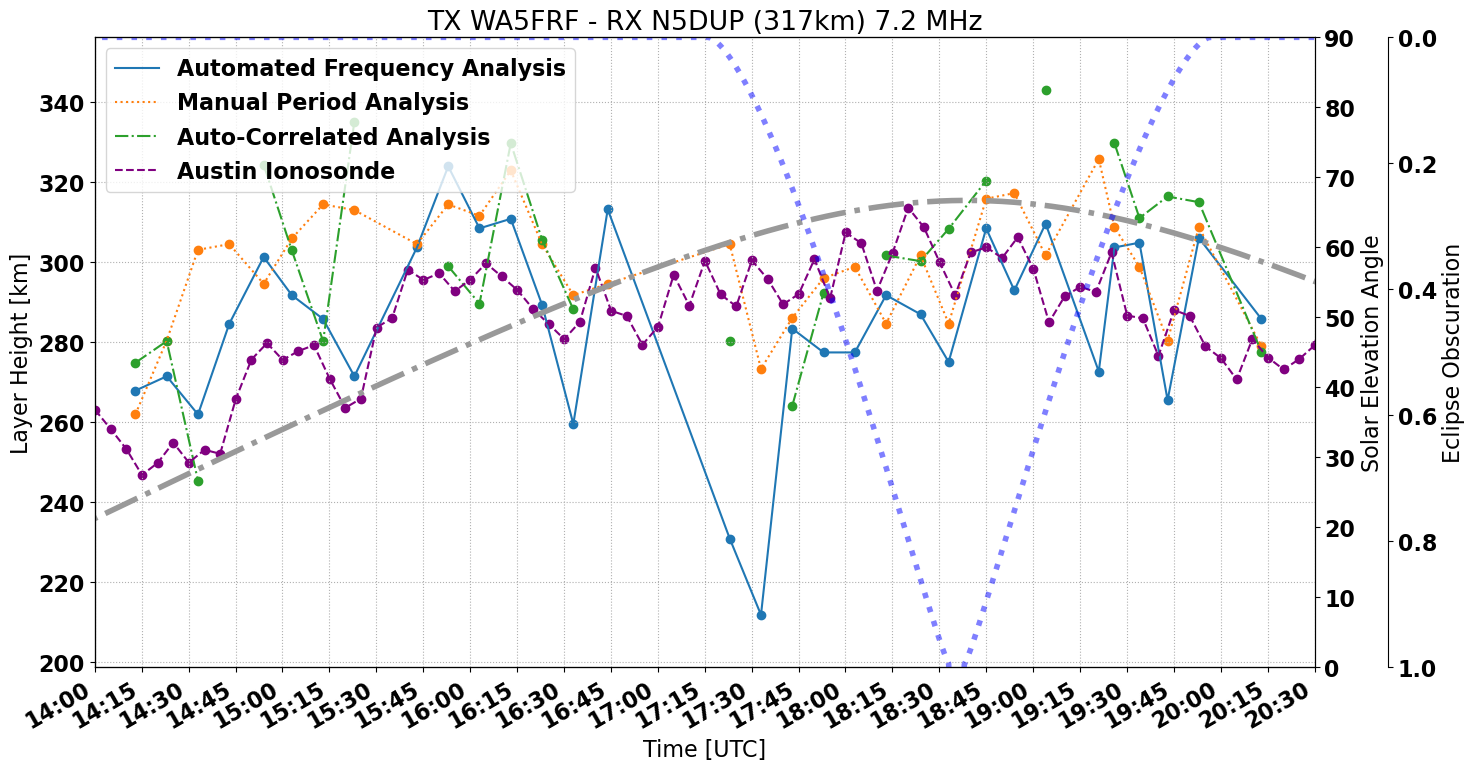

Figure saved to /Users/r01344106/code/frontiers/HF-TDOA-Frontiers-2025/fig_11_12/notebooks/fig_11_N5DUP2024.jpg


In [10]:
TDOAS_PAUL40, _ = post_processing_normal(
    beats_40m,
    "TX WA5FRF - RX N5DUP (317km) 7.2 MHz",
    times=fortyBand_times,
    plot_TDOAs=True,
    manual_TDOAs=ManuallyDecodedN5DUP40m,
    obscuration_times=eclipse_times,
    obscuration_values=obsc_N5,
    correlated_TDOAS=AutoCorrelatedN5DUP40m,
    solar_val=solarN5,
    lat=lat_N5,
    lon=lon_N5,
    save_path=OUTPUT_FIG11 / 'fig_11_N5DUP2024.jpg',
)
print(f"Figure saved to {OUTPUT_FIG11 / 'fig_11_N5DUP2024.jpg'}")


## Generate Figure 12 (panels a and b)

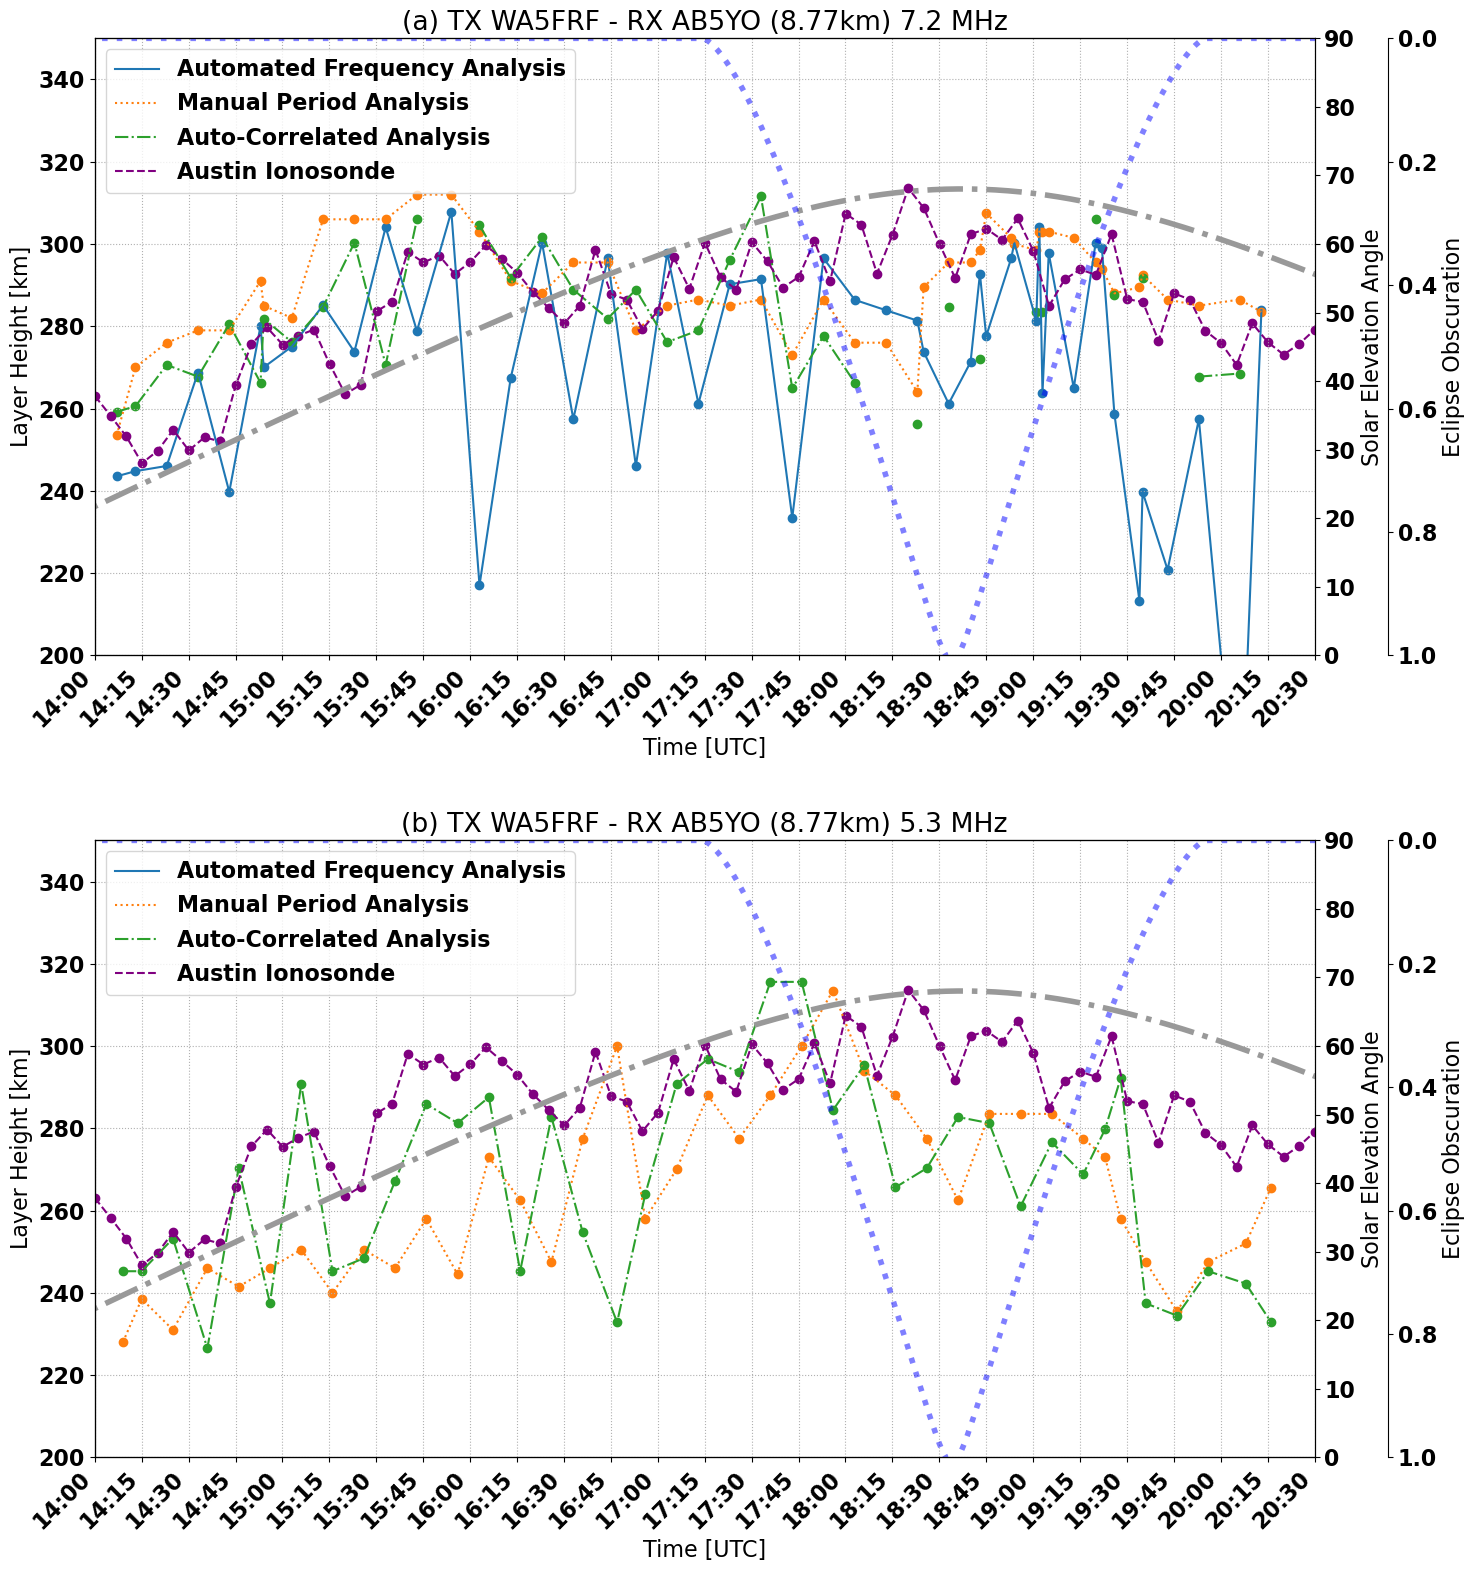

Figure saved to /Users/r01344106/code/frontiers/HF-TDOA-Frontiers-2025/fig_11_12/notebooks/fig_12_2024Res.jpg


In [11]:
result = post_processing_normal_dual(
    dict_args1={
        "beats": beats_40mSam,
        "set_name": "TX WA5FRF - RX AB5YO (8.77km) 7.2 MHz",
        "times": fortymSamBand_times,
        "manual_TDOAs": ManuallyDecodedAB5YO40m,
        "obscuration_times": eclipse_times,
        "obscuration_values": obsc_AB,
        "correlated_TDOAS": AutoCorrelatedAB5YO40m,
        "solar_val": solarAB,
        "lat": lat_AB,
        "lon": lon_AB
    },
    dict_args2={
        "beats": beats_60mSam,
        "set_name": "TX WA5FRF - RX AB5YO (8.77km) 5.3 MHz",
        "times": sixtymSamBand_times,
        "manual_TDOAs": ManuallyDecodedAB5YO60m,
        "obscuration_times": eclipse_times,
        "obscuration_values": obsc_AB,
        "correlated_TDOAS": AutoCorrelatedAB5YO60m,
        "solar_val": solarAB,
        "lat": lat_AB,
        "lon": lon_AB
    },
    save_path=OUTPUT_FIG12 / 'fig_12_2024Res.jpg'
)
print(f"Figure saved to {OUTPUT_FIG12 / 'fig_12_2024Res.jpg'}")